<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_1/blob/main/7_1_1_PRACTICE_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering

1. Missing data
2. Feature Normalization
3. Categorical Encoding
4. Transformations
5. Discretization
6. Outliers
7. Optional: Date and Time

---
## 1. Missing data

In [1]:
import pylab
import datetime
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [2]:
!gdown "160gAZCXP4ru26txQo-MYJISet-ASMNR9"

titanic = pd.read_csv('titanic.csv')

Downloading...
From: https://drive.google.com/uc?id=160gAZCXP4ru26txQo-MYJISet-ASMNR9
To: /content/titanic.csv
100% 61.2k/61.2k [00:00<00:00, 3.88MB/s]


In [3]:
data0 = titanic.copy()

In [4]:
data0.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
print(f'Percentage of data without missing values: {data0.dropna().shape[0]/ float(data0.shape[0])}')

Percentage of data without missing values: 0.2053872053872054


In [7]:
data1 = titanic.copy()

In [8]:
data1.isna().mean()

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198653
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [9]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**TODO:** `Age` is a continuous variable. First, we will check the distribution of `age` variable.

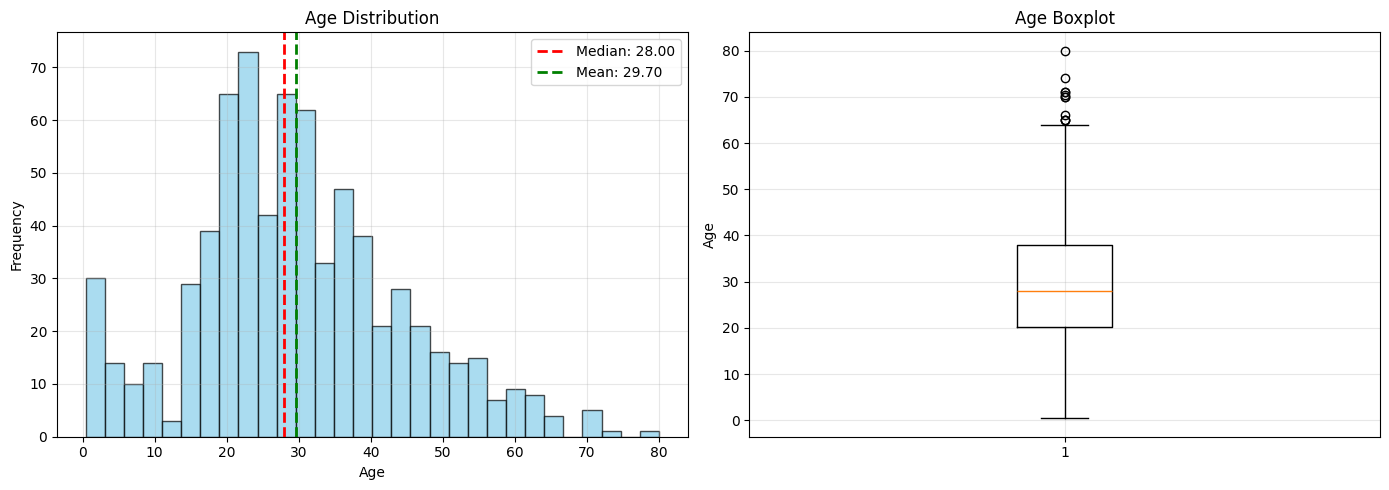

Age Statistics:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

Skewness: 0.3891


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data1['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].axvline(data1['Age'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {data1["Age"].median():.2f}')
axes[0].axvline(data1['Age'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {data1["Age"].mean():.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].boxplot(data1['Age'].dropna(), vert=True)
axes[1].set_ylabel('Age')
axes[1].set_title('Age Boxplot')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Age Statistics:")
print(data1['Age'].describe())
print(f"\nSkewness: {data1['Age'].skew():.4f}")

**TODO:** We can see that the `age` distribution is skewed. So, we will use the median imputation.

In [11]:
data2 = data1.copy()

median = data2['Age'].median()
print(f'Median Age: {median}')

data2['Age'] = data2['Age'].fillna(median)

print(f'\nMissing Age values after imputation: {data2["Age"].isna().sum()}')

data2.head()

Median Age: 28.0

Missing Age values after imputation: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


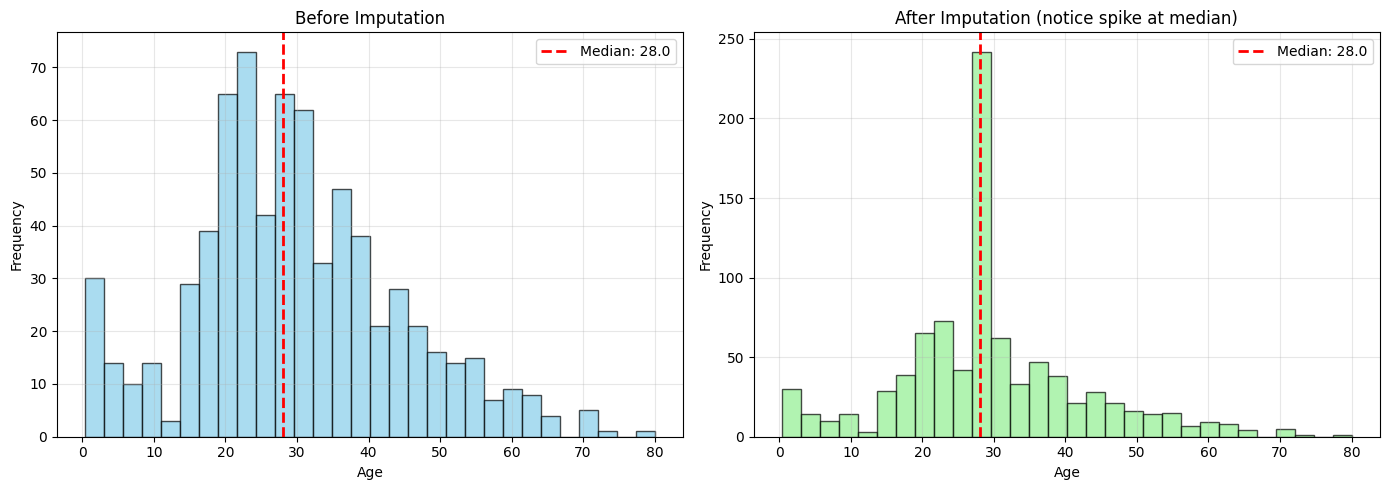

Before: 177 missing values
After: 0 missing values


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data1['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Before Imputation')
axes[0].axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(data2['Age'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].set_title('After Imputation (notice spike at median)')
axes[1].axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Before: {data1["Age"].isna().sum()} missing values')
print(f'After: {data2["Age"].isna().sum()} missing values')

---
## 2. Feature Normalization

In [13]:
data2 = titanic.copy()
median = data2.Age.median()
data2['Age'] = data2['Age'].fillna(median)
data2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**TODO:** We are going to normalize the Age in two ways using MinMax Scaler and Standard Scaler

MinMax Normalization Results:
Original Age range: [0.42, 80.00]
Normalized Age range: [0.00, 1.00]

First 5 rows:
    Age  Age_MinMax
0  22.0    0.271174
1  38.0    0.472229
2  26.0    0.321438
3  35.0    0.434531
4  35.0    0.434531
Standard Scaler Normalization Results:
Original Age - Mean: 29.36, Std: 13.02
Normalized Age - Mean: 0.0000, Std: 1.00

First 5 rows:
    Age  Age_Standard
0  22.0     -0.565736
1  38.0      0.663861
2  26.0     -0.258337
3  35.0      0.433312
4  35.0      0.433312


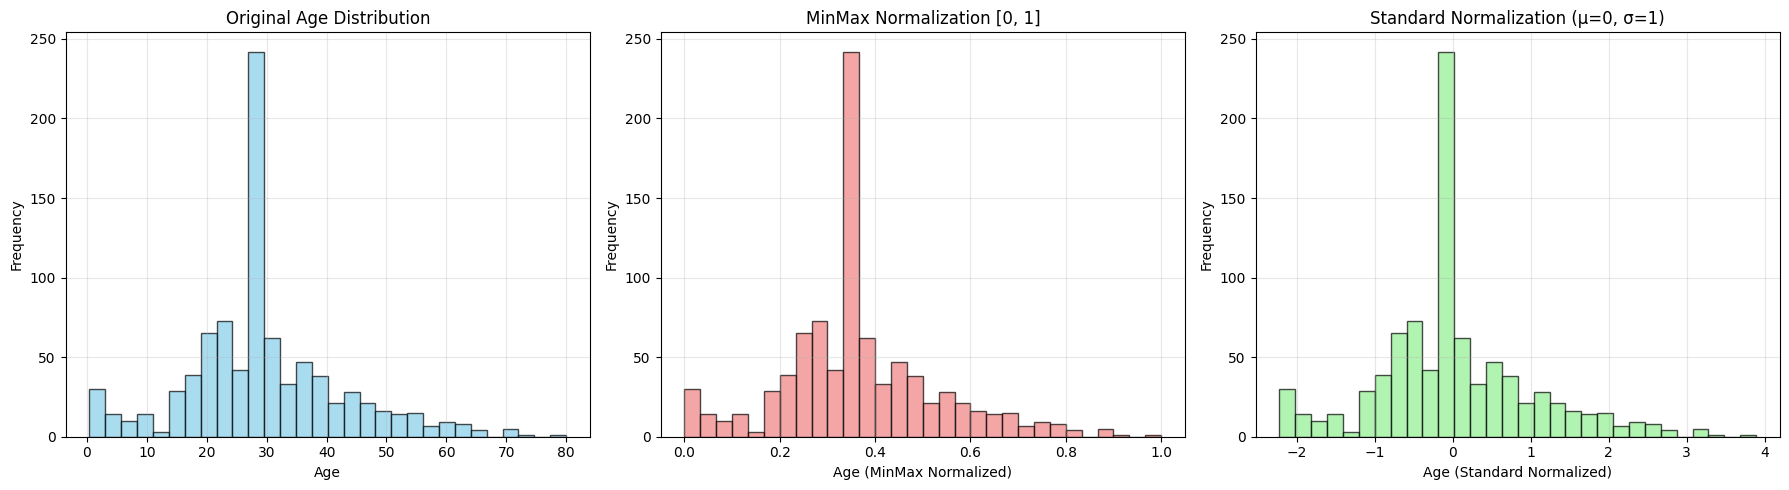

Normalization Comparison:
Metric  Original Age  MinMax Normalized  Standard Normalized
   Min      0.420000           0.000000        -2.224156e+00
   Max     80.000000           1.000000         3.891554e+00
  Mean     29.361582           0.363679         2.272780e-16
   Std     13.019697           0.163605         1.000562e+00
Median     28.000000           0.346569        -1.046374e-01


In [14]:
from sklearn.preprocessing import MinMaxScaler

data_minmax = data2.copy()

scaler_minmax = MinMaxScaler()

data_minmax['Age_MinMax'] = scaler_minmax.fit_transform(data_minmax[['Age']])

print("MinMax Normalization Results:")
print(f"Original Age range: [{data2['Age'].min():.2f}, {data2['Age'].max():.2f}]")
print(f"Normalized Age range: [{data_minmax['Age_MinMax'].min():.2f}, {data_minmax['Age_MinMax'].max():.2f}]")
print("\nFirst 5 rows:")
print(data_minmax[['Age', 'Age_MinMax']].head())

from sklearn.preprocessing import StandardScaler

data_standard = data2.copy()

scaler_standard = StandardScaler()

data_standard['Age_Standard'] = scaler_standard.fit_transform(data_standard[['Age']])

print("Standard Scaler Normalization Results:")
print(f"Original Age - Mean: {data2['Age'].mean():.2f}, Std: {data2['Age'].std():.2f}")
print(f"Normalized Age - Mean: {data_standard['Age_Standard'].mean():.4f}, Std: {data_standard['Age_Standard'].std():.2f}")
print("\nFirst 5 rows:")
print(data_standard[['Age', 'Age_Standard']].head())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(data2['Age'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Age Distribution')
axes[0].grid(alpha=0.3)

axes[1].hist(data_minmax['Age_MinMax'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Age (MinMax Normalized)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('MinMax Normalization [0, 1]')
axes[1].grid(alpha=0.3)

axes[2].hist(data_standard['Age_Standard'], bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[2].set_xlabel('Age (Standard Normalized)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Standard Normalization (μ=0, σ=1)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

import pandas as pd

comparison = pd.DataFrame({
    'Metric': ['Min', 'Max', 'Mean', 'Std', 'Median'],
    'Original Age': [
        data2['Age'].min(),
        data2['Age'].max(),
        data2['Age'].mean(),
        data2['Age'].std(),
        data2['Age'].median()
    ],
    'MinMax Normalized': [
        data_minmax['Age_MinMax'].min(),
        data_minmax['Age_MinMax'].max(),
        data_minmax['Age_MinMax'].mean(),
        data_minmax['Age_MinMax'].std(),
        data_minmax['Age_MinMax'].median()
    ],
    'Standard Normalized': [
        data_standard['Age_Standard'].min(),
        data_standard['Age_Standard'].max(),
        data_standard['Age_Standard'].mean(),
        data_standard['Age_Standard'].std(),
        data_standard['Age_Standard'].median()
    ]
})

print("Normalization Comparison:")
print(comparison.to_string(index=False))


---
## 3. Categorical Encoding

### One-Hot Encoding

In [19]:
data3 = titanic.copy()

print("Sex variable:")
print(data3['Sex'].head())
print(f"\nUnique values: {data3['Sex'].unique()}")
print(f"Value counts:\n{data3['Sex'].value_counts()}")

Sex variable:
0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: object

Unique values: ['male' 'female']
Value counts:
Sex
male      577
female    314
Name: count, dtype: int64


In [21]:
data3['Sex'].head()

,Sex
0,male
1,female
2,female
3,female
4,male


In [17]:
data3_oh = pd.get_dummies(data3['Sex'])
data3_oh.head()

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


In [22]:
data3 = data3.join(data3_oh)
data3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,female,male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,True


We can see that we only need 1 of the 2 dummy variables to represent the original categorical variable `Sex`. Any of the 2 will do the job, and it doesn't matter which one we select, since they are equivalent. Therefore, to encode a categorical variable with 2 labels, we need only 1 dummy variable.

To extend this concept, to encode categorical variable with k labels, we need k-1 dummy variables. We can achieve this task as follows:

**TODO:** Obtaining k-1 labels on __Sex__ and __Embarked__ features

In [26]:
# TODO: Obtaining k-1 labels on Sex and Embarked features
data3_encoded = titanic.copy()

sex_encoded = pd.get_dummies(data3_encoded['Sex'], prefix='Sex', drop_first=True)
print("Sex encoding (k-1):")
print(sex_encoded.head())
print(f"\nColumns created: {sex_encoded.columns.tolist()}")

embarked_encoded = pd.get_dummies(data3_encoded['Embarked'], prefix='Embarked', drop_first=True)
print("\n\nEmbarked encoding (k-1):")
print(embarked_encoded.head())
print(f"\nColumns created: {embarked_encoded.columns.tolist()}")

data3_encoded = data3_encoded.join(sex_encoded)
data3_encoded = data3_encoded.join(embarked_encoded)

print("Dataset with encoded variables:")
data3_encoded[['Sex', 'Sex_male', 'Embarked', 'Embarked_Q', 'Embarked_S']].head(10)

Sex encoding (k-1):
   Sex_male
0      True
1     False
2     False
3     False
4      True

Columns created: ['Sex_male']


Embarked encoding (k-1):
   Embarked_Q  Embarked_S
0       False        True
1       False       False
2       False        True
3       False        True
4       False        True

Columns created: ['Embarked_Q', 'Embarked_S']
Dataset with encoded variables:


,Sex,Sex_male,Embarked,Embarked_Q,Embarked_S
0,male,True,S,False,True
1,female,False,C,False,False
2,female,False,S,False,True
3,female,False,S,False,True
4,male,True,S,False,True
5,male,True,Q,True,False
6,male,True,S,False,True
7,male,True,S,False,True
8,female,False,S,False,True
9,female,False,C,False,False


**TODO:** Investigate Scikt-Learn API [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [27]:
# TODO: Investigate Scikit-Learn API one-hot encoding

from sklearn.preprocessing import OneHotEncoder
import numpy as np

encoder = OneHotEncoder(drop='first', sparse_output=False)

sex_embarked = data3_encoded[['Sex', 'Embarked']].copy()

encoded_array = encoder.fit_transform(sex_embarked)

feature_names = encoder.get_feature_names_out(['Sex', 'Embarked'])

sklearn_encoded = pd.DataFrame(encoded_array, columns=feature_names)

print("Scikit-Learn OneHotEncoder Result:")
print(sklearn_encoded.head(10))
print(f"\nFeature names: {feature_names}")
print(f"\nCategories per feature: {encoder.categories_}")

Scikit-Learn OneHotEncoder Result:
   Sex_male  Embarked_Q  Embarked_S  Embarked_nan
0       1.0         0.0         1.0           0.0
1       0.0         0.0         0.0           0.0
2       0.0         0.0         1.0           0.0
3       0.0         0.0         1.0           0.0
4       1.0         0.0         1.0           0.0
5       1.0         1.0         0.0           0.0
6       1.0         0.0         1.0           0.0
7       1.0         0.0         1.0           0.0
8       0.0         0.0         1.0           0.0
9       0.0         0.0         0.0           0.0

Feature names: ['Sex_male' 'Embarked_Q' 'Embarked_S' 'Embarked_nan']

Categories per feature: [array(['female', 'male'], dtype=object), array(['C', 'Q', 'S', nan], dtype=object)]


---
## 4 Transformations

In [35]:
data4 = pd.read_csv('titanic.csv', usecols=['Age', 'Fare', 'Survived'])
data4.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [36]:
data4['Age'] = data4['Age'].fillna(data4.Age.median())
data4.isna().sum()

,0
Survived,0
Age,0
Fare,0


### Example: Logarithmic transformation

In [37]:
data4['Age_log'] = np.log(data4.Age)

**TODO:** Convert Age to months

In [49]:
# TODO: Convert Age to months
data4['Age_months'] = data4['Age'] * 12

data4[['Age', 'Age_months']].head(10)

print("Age to Months Conversion:")
print(data4[['Age', 'Age_log', 'Age_months']].describe())

Age to Months Conversion:
              Age     Age_log  Age_months
count  891.000000  891.000000  891.000000
mean    29.361582    3.222903  352.338990
std     13.019697    0.704399  156.236359
min      0.420000   -0.867501    5.040000
25%     22.000000    3.091042  264.000000
50%     28.000000    3.332205  336.000000
75%     35.000000    3.555348  420.000000
max     80.000000    4.382027  960.000000


---
## 5. Discretization

**TODO:** Apply binning to __Age__ and plot Age count per bin

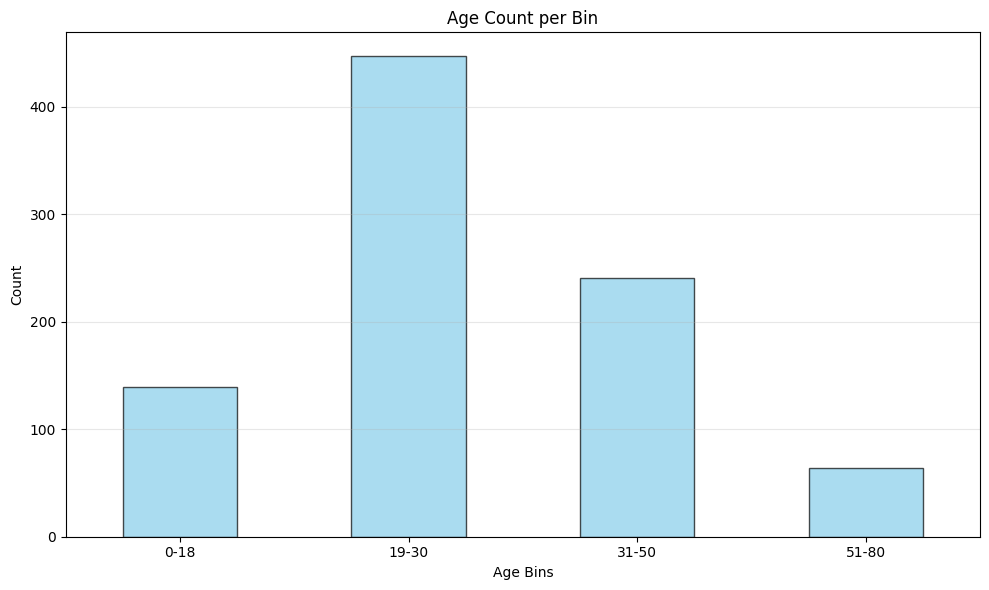

Age count per bin:
Age_binned
0-18     139
19-30    447
31-50    241
51-80     64
Name: count, dtype: int64


In [41]:
# TODO: Apply binning to Age and plot Age count per bin

data5 = titanic.copy()
data5['Age'] = data5['Age'].fillna(data5['Age'].median())

bins = [0, 18, 30, 50, 80]
labels = ['0-18', '19-30', '31-50', '51-80']
data5['Age_binned'] = pd.cut(data5['Age'], bins=bins, labels=labels)

age_bin_counts = data5['Age_binned'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
age_bin_counts.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Age Bins')
plt.ylabel('Count')
plt.title('Age Count per Bin')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Age count per bin:")
print(age_bin_counts)

---
## 6. Outliers

**TODO:** Load the numerical variables of the Titanic Dataset

In [42]:
# TODO: Load the numerical variables of the Titanic Dataset
data6 = titanic.copy()

numerical_cols = data6.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical variables in Titanic Dataset:")
print(numerical_cols)

print("\nNumerical data:")
print(data6[numerical_cols].head())

Numerical variables in Titanic Dataset:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Numerical data:
   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare
0            1         0       3  22.0      1      0   7.2500
1            2         1       1  38.0      1      0  71.2833
2            3         1       3  26.0      0      0   7.9250
3            4         1       1  35.0      1      0  53.1000
4            5         0       3  35.0      0      0   8.0500


**TODO:** We can see that `Age` and `Fare` are continuous variables. So, you'll need to limit outliers on those variables.

In [43]:
# TODO: We can see that Age and Fare are continuous variables.

data6['Age'] = data6['Age'].fillna(data6['Age'].median())

print("Age and Fare statistics (before outlier treatment):")
print(data6[['Age', 'Fare']].describe())

Age and Fare statistics (before outlier treatment):
              Age        Fare
count  891.000000  891.000000
mean    29.361582   32.204208
std     13.019697   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200


**TODO:** Plot histograms on __Age__ and __Fare__

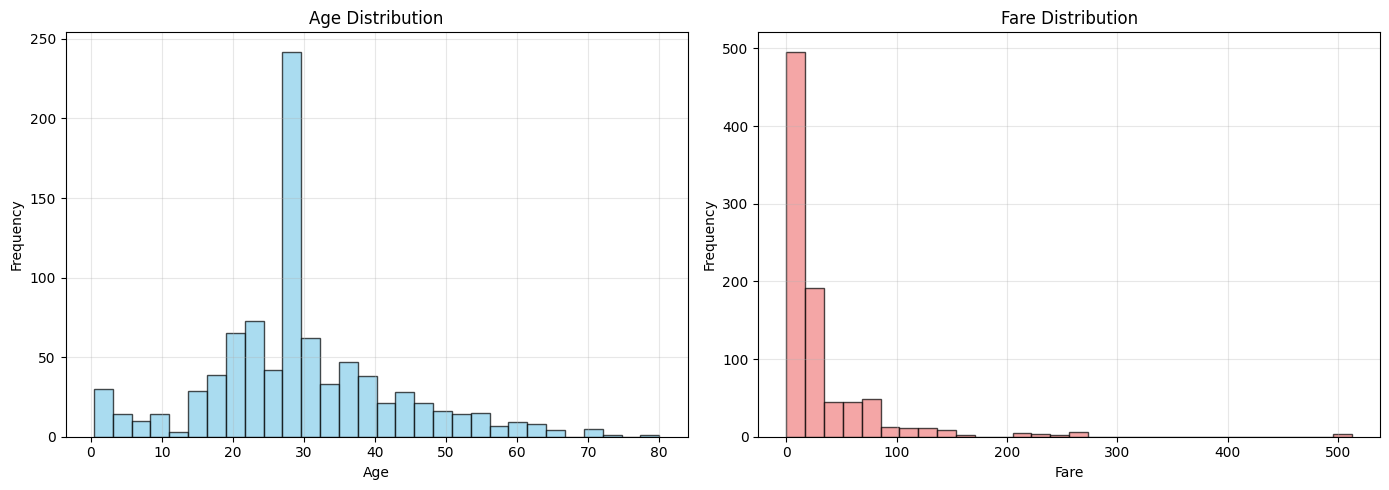

In [44]:
# TODO: Plot histograms on Age and Fare

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age histogram
axes[0].hist(data6['Age'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')
axes[0].grid(alpha=0.3)

# Fare histogram
axes[1].hist(data6['Fare'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Fare Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**TODO:** __Age__ is quite Gaussian and __Fare__ is skewed, so you will use the Gaussian assumption for __Age__, and the interquantile range for __Fare__.

In [45]:
# TODO: Age is quite Gaussian and Fare is skewed

# Method 1: Gaussian assumption for Age (mean ± 3*std)
age_mean = data6['Age'].mean()
age_std = data6['Age'].std()

age_lower = age_mean - 3 * age_std
age_upper = age_mean + 3 * age_std

print("Age outlier detection (Gaussian assumption - 3 sigma rule):")
print(f"Mean: {age_mean:.2f}")
print(f"Std: {age_std:.2f}")
print(f"Lower bound: {age_lower:.2f}")
print(f"Upper bound: {age_upper:.2f}")

age_outliers = data6[(data6['Age'] < age_lower) | (data6['Age'] > age_upper)]
print(f"Number of Age outliers: {len(age_outliers)}")

Q1_fare = data6['Fare'].quantile(0.25)
Q3_fare = data6['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

fare_lower = Q1_fare - 1.5 * IQR_fare
fare_upper = Q3_fare + 1.5 * IQR_fare

print("\n" + "="*60)
print("Fare outlier detection (Interquartile Range - IQR method):")
print(f"Q1: {Q1_fare:.2f}")
print(f"Q3: {Q3_fare:.2f}")
print(f"IQR: {IQR_fare:.2f}")
print(f"Lower bound: {fare_lower:.2f}")
print(f"Upper bound: {fare_upper:.2f}")

fare_outliers = data6[(data6['Fare'] < fare_lower) | (data6['Fare'] > fare_upper)]
print(f"Number of Fare outliers: {len(fare_outliers)}")

Age outlier detection (Gaussian assumption - 3 sigma rule):
Mean: 29.36
Std: 13.02
Lower bound: -9.70
Upper bound: 68.42
Number of Age outliers: 7

Fare outlier detection (Interquartile Range - IQR method):
Q1: 7.91
Q3: 31.00
IQR: 23.09
Lower bound: -26.72
Upper bound: 65.63
Number of Fare outliers: 116


### Find outliers

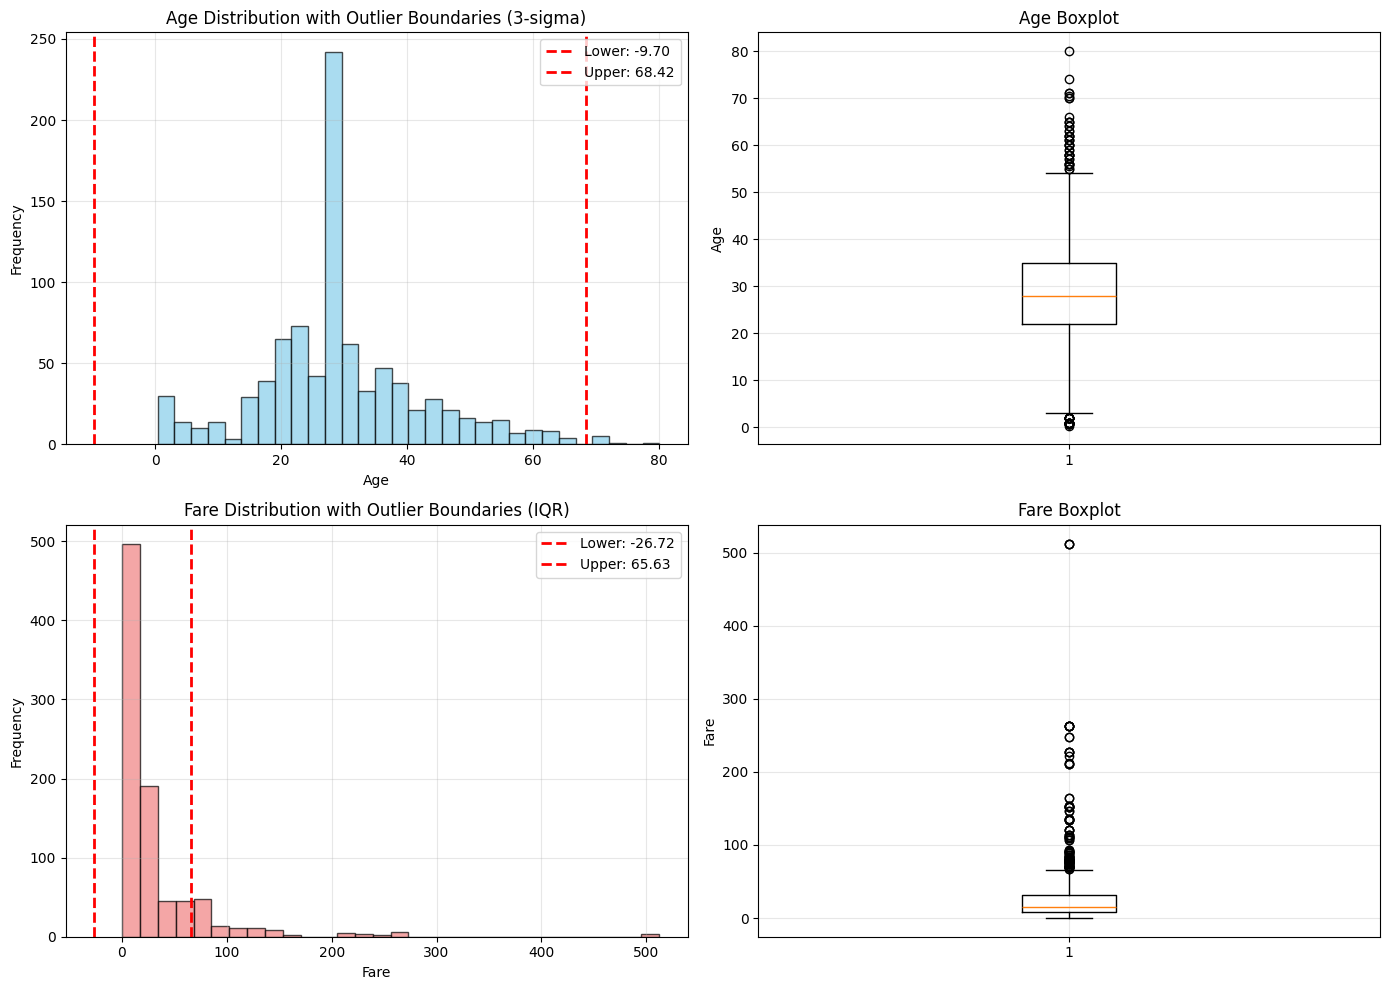

In [46]:
# Find outliers - Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(data6['Age'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(age_lower, color='red', linestyle='--', linewidth=2, label=f'Lower: {age_lower:.2f}')
axes[0, 0].axvline(age_upper, color='red', linestyle='--', linewidth=2, label=f'Upper: {age_upper:.2f}')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Age Distribution with Outlier Boundaries (3-sigma)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].boxplot(data6['Age'], vert=True)
axes[0, 1].set_ylabel('Age')
axes[0, 1].set_title('Age Boxplot')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].hist(data6['Fare'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
axes[1, 0].axvline(fare_lower, color='red', linestyle='--', linewidth=2, label=f'Lower: {fare_lower:.2f}')
axes[1, 0].axvline(fare_upper, color='red', linestyle='--', linewidth=2, label=f'Upper: {fare_upper:.2f}')
axes[1, 0].set_xlabel('Fare')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Fare Distribution with Outlier Boundaries (IQR)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].boxplot(data6['Fare'], vert=True)
axes[1, 1].set_ylabel('Fare')
axes[1, 1].set_title('Fare Boxplot')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Optional: Date and Time

In some machine learning problems, temporary features appear, such as dates, times, etc. That type of data must be treated in a particular way.

**NOTE:** There is an area of machine learning where time data becomes critical, time series.

In [47]:
!gdown "1FFgCIxCy-DLV_mlzyFk_RolEgcr8IDNQ"

data7 = pd.read_csv('stock_prices.csv')
data7.head()

Downloading...
From: https://drive.google.com/uc?id=1FFgCIxCy-DLV_mlzyFk_RolEgcr8IDNQ
To: /content/stock_prices.csv
100% 20.5k/20.5k [00:00<00:00, 42.3MB/s]


,Date,Close Price,High Price,Low Price,Open Price,Volume
0,2021-12-10 05AM,48246.57,48359.35,48051.08,48170.66,827.39761
1,2021-12-10 06AM,47847.59,48430.00,47810.81,48249.78,1296.18883
2,2021-12-10 07AM,47694.62,48037.48,47550.00,47847.59,2299.85298
3,2021-12-10 08AM,48090.35,48169.06,47587.39,47694.62,1371.25447
4,2021-12-10 09AM,48366.37,48495.00,47869.80,48090.35,1232.30238


**TODO:** Parse the dates, currently coded as strings, into datetime.

**TIP:** Investigate pandas [to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) and take care of date format!

In [50]:
# TODO: Parse the dates, currently coded as strings, into datetime.

data7['Date'] = pd.to_datetime(data7['Date'], format='mixed', errors='coerce')

if data7['Date'].isna().any():
    print("\nWarning: Some dates could not be parsed and were set to NaT. Inspect these entries:")
    print(data7[data7['Date'].isna()])

print("\nDate column type after conversion:", data7['Date'].dtype)
print("\nFirst 5 dates after conversion:")
print(data7['Date'].head())


    Date  Close Price  High Price  Low Price  Open Price      Volume
8    NaT     49610.99    50125.00   48850.00    49092.20  3660.60271
9    NaT     48275.50    49839.65   48126.00    49611.00  3760.96141
10   NaT     47979.22    48604.44   47744.19    48275.50  3260.50106
11   NaT     47533.58    48002.35   47251.06    47979.23  3732.90429
12   NaT     47713.65    47750.10   47291.78    47535.98  1868.14639
..   ...          ...         ...        ...         ...         ...
326  NaT     51109.99    51375.00   50500.00    50619.98  2934.34312
327  NaT     50929.71    51209.30   50718.66    51110.00  1825.89043
328  NaT     50824.37    50980.99   50622.75    50929.71  1290.12677
329  NaT     50758.94    50998.72   50706.45    50824.37   858.21201
330  NaT     50838.81    50851.11   50501.00    50758.94  1048.89266

[154 rows x 6 columns]

Date column type after conversion: datetime64[ns]

First 5 dates after conversion:
0   2021-12-10 05:00:00
1   2021-12-10 06:00:00
2   2021-12-10 

**TODO:** Extract Month from Date

In [51]:
# TODO: Extract Month from Date

data7['Month'] = data7['Date'].dt.month

print("Month extracted:")
print(data7[['Date', 'Month']].head(10))

Month extracted:
                 Date  Month
0 2021-12-10 05:00:00   12.0
1 2021-12-10 06:00:00   12.0
2 2021-12-10 07:00:00   12.0
3 2021-12-10 08:00:00   12.0
4 2021-12-10 09:00:00   12.0
5 2021-12-10 10:00:00   12.0
6 2021-12-10 11:00:00   12.0
7 2021-12-10 12:00:00   12.0
8                 NaT    NaN
9                 NaT    NaN


**TODO:** Convert Day to numeric from 1-31

In [52]:
# TODO: Convert Day to numeric from 1-31

data7['Day'] = data7['Date'].dt.day

print("Day of month extracted (1-31):")
print(data7[['Date', 'Day']].head(10))

Day of month extracted (1-31):
                 Date   Day
0 2021-12-10 05:00:00  10.0
1 2021-12-10 06:00:00  10.0
2 2021-12-10 07:00:00  10.0
3 2021-12-10 08:00:00  10.0
4 2021-12-10 09:00:00  10.0
5 2021-12-10 10:00:00  10.0
6 2021-12-10 11:00:00  10.0
7 2021-12-10 12:00:00  10.0
8                 NaT   NaN
9                 NaT   NaN


**TODO:** Convert Day of the week to numeric from 0 to 6

In [53]:
# TODO: Convert Day of the week to numeric from 0 to 6

data7['DayOfWeek'] = data7['Date'].dt.dayofweek

print("Day of week extracted (0=Monday, 6=Sunday):")
print(data7[['Date', 'DayOfWeek']].head(10))

Day of week extracted (0=Monday, 6=Sunday):
                 Date  DayOfWeek
0 2021-12-10 05:00:00        4.0
1 2021-12-10 06:00:00        4.0
2 2021-12-10 07:00:00        4.0
3 2021-12-10 08:00:00        4.0
4 2021-12-10 09:00:00        4.0
5 2021-12-10 10:00:00        4.0
6 2021-12-10 11:00:00        4.0
7 2021-12-10 12:00:00        4.0
8                 NaT        NaN
9                 NaT        NaN


**TODO:** Convert Day of the week to name

In [54]:
# TODO: Convert Day of the week to name

data7['DayOfWeek_Name'] = data7['Date'].dt.day_name()

print("Day of week name extracted:")
print(data7[['Date', 'DayOfWeek', 'DayOfWeek_Name']].head(10))

Day of week name extracted:
                 Date  DayOfWeek DayOfWeek_Name
0 2021-12-10 05:00:00        4.0         Friday
1 2021-12-10 06:00:00        4.0         Friday
2 2021-12-10 07:00:00        4.0         Friday
3 2021-12-10 08:00:00        4.0         Friday
4 2021-12-10 09:00:00        4.0         Friday
5 2021-12-10 10:00:00        4.0         Friday
6 2021-12-10 11:00:00        4.0         Friday
7 2021-12-10 12:00:00        4.0         Friday
8                 NaT        NaN            NaN
9                 NaT        NaN            NaN


**TODO:** Was on Weekend? Generate a binary feature that indicates if the date corresponds to a weekend day.

In [55]:
# TODO: Was on Weekend? Generate a binary feature that indicates
# if the date corresponds to a weekend day.

# Weekend: Saturday (5) or Sunday (6)
data7['IsWeekend'] = (data7['DayOfWeek'] >= 5).astype(int)

print("Weekend binary feature (1=Weekend, 0=Weekday):")
print(data7[['Date', 'DayOfWeek_Name', 'IsWeekend']].head(10))

print("\nWeekend distribution:")
print(data7['IsWeekend'].value_counts())

Weekend binary feature (1=Weekend, 0=Weekday):
                 Date DayOfWeek_Name  IsWeekend
0 2021-12-10 05:00:00         Friday          0
1 2021-12-10 06:00:00         Friday          0
2 2021-12-10 07:00:00         Friday          0
3 2021-12-10 08:00:00         Friday          0
4 2021-12-10 09:00:00         Friday          0
5 2021-12-10 10:00:00         Friday          0
6 2021-12-10 11:00:00         Friday          0
7 2021-12-10 12:00:00         Friday          0
8                 NaT            NaN          0
9                 NaT            NaN          0

Weekend distribution:
IsWeekend
0    285
1     52
Name: count, dtype: int64


**TODO:** Extract year

In [56]:
# TODO: Extract year

data7['Year'] = data7['Date'].dt.year

print("Year extracted:")
print(data7[['Date', 'Year']].head(10))

Year extracted:
                 Date    Year
0 2021-12-10 05:00:00  2021.0
1 2021-12-10 06:00:00  2021.0
2 2021-12-10 07:00:00  2021.0
3 2021-12-10 08:00:00  2021.0
4 2021-12-10 09:00:00  2021.0
5 2021-12-10 10:00:00  2021.0
6 2021-12-10 11:00:00  2021.0
7 2021-12-10 12:00:00  2021.0
8                 NaT     NaN
9                 NaT     NaN


**TODO:** Extract hour

In [57]:
# TODO: Extract hour

data7['Hour'] = data7['Date'].dt.hour

print("Hour extracted:")
print(data7[['Date', 'Hour']].head(10))

Hour extracted:
                 Date  Hour
0 2021-12-10 05:00:00   5.0
1 2021-12-10 06:00:00   6.0
2 2021-12-10 07:00:00   7.0
3 2021-12-10 08:00:00   8.0
4 2021-12-10 09:00:00   9.0
5 2021-12-10 10:00:00  10.0
6 2021-12-10 11:00:00  11.0
7 2021-12-10 12:00:00  12.0
8                 NaT   NaN
9                 NaT   NaN


In [58]:
# Summary of all date/time features extracted

print("All date/time features:")
print(data7[['Date', 'Month', 'Day', 'DayOfWeek', 'DayOfWeek_Name',
             'IsWeekend', 'Year', 'Hour']].head(10))

print("\nDataset shape:", data7.shape)
print("New columns created:", ['Month', 'Day', 'DayOfWeek', 'DayOfWeek_Name',
                                 'IsWeekend', 'Year', 'Hour'])

All date/time features:
                 Date  Month   Day  DayOfWeek DayOfWeek_Name  IsWeekend  \
0 2021-12-10 05:00:00   12.0  10.0        4.0         Friday          0   
1 2021-12-10 06:00:00   12.0  10.0        4.0         Friday          0   
2 2021-12-10 07:00:00   12.0  10.0        4.0         Friday          0   
3 2021-12-10 08:00:00   12.0  10.0        4.0         Friday          0   
4 2021-12-10 09:00:00   12.0  10.0        4.0         Friday          0   
5 2021-12-10 10:00:00   12.0  10.0        4.0         Friday          0   
6 2021-12-10 11:00:00   12.0  10.0        4.0         Friday          0   
7 2021-12-10 12:00:00   12.0  10.0        4.0         Friday          0   
8                 NaT    NaN   NaN        NaN            NaN          0   
9                 NaT    NaN   NaN        NaN            NaN          0   

     Year  Hour  
0  2021.0   5.0  
1  2021.0   6.0  
2  2021.0   7.0  
3  2021.0   8.0  
4  2021.0   9.0  
5  2021.0  10.0  
6  2021.0  11.0  
7  202